<a href="https://colab.research.google.com/github/mopuriapurva/DSA0404-FODS/blob/main/CO2-AT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ALL LIBRARIES IMPORTED SUCCESSFULLY

PART 1: Creating Sample DataFrame

     Name  Age  Student
0    John   20     True
1    Emma   19     True
2    Liam   21    False
3  Olivia   18     True

Adding New Row

     Name  Age  Student
0    John   20     True
1    Emma   19     True
2    Liam   21    False
3  Olivia   18     True
4  Sophia   22    False

PART 2: DATA PREPROCESSING

Raw Data
  Employee_Name   Department   Salary   Join_Date
0        Alice            HR  50000.0  2022-01-15
1           Bob  Engineering  85000.0  2021-06-20
2       Charlie           HR      NaN  2023-03-11
3         Diana  Engineering  92000.0  2020-11-01
4          Evan    Marketing  60000.0  2024-02-28

Preprocessed Data
  Employee_Name   Department   Salary  Join_Date  Years_of_Service
0         Alice           HR  50000.0 2022-01-15                 4
1           Bob  Engineering  85000.0 2021-06-20                 5
2       Charlie           HR  72500.0 2023-03-11                 3
3         Diana  Engin

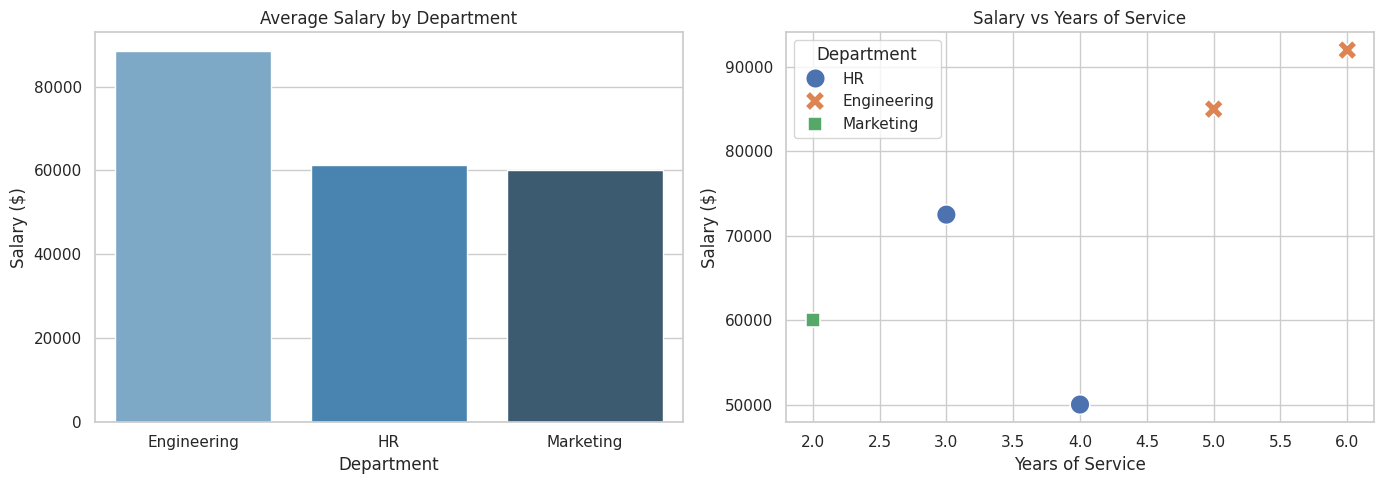


PART 3: SCIPY EXAMPLES

Measures of Central Tendency
Mean: 30.0
Median: 30.0
Mode: 10
Mode Count: 1

Probability Distribution
Probability: 0.9331927987311419

One Sample t-Test
T-Statistic: -0.2049800154226962
P-Value: 0.8456711339658732

Correlation Analysis
Correlation: 1.0
P-Value: 0.0

Linear Algebra
Solution: [0.  2.5]

Optimisation
Optimal x: [-2.62955131e-08]

PART 4: MACHINE LEARNING - LOGISTIC REGRESSION
Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Program Executed Successfully.


In [1]:
# ============================================================
# INSTALL LIBRARIES (Run only if required)
# ============================================================
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, pearsonr
from scipy import linalg
from scipy.optimize import minimize

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("=" * 60)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

# ============================================================
# PART 1: CREATING SAMPLE DATAFRAME
# ============================================================

print("\nPART 1: Creating Sample DataFrame\n")

df = pd.DataFrame()

df["Name"] = ["John", "Emma", "Liam", "Olivia"]
df["Age"] = [20, 19, 21, 18]
df["Student"] = [True, True, False, True]

print(df)

# ============================================================
# ADDING A NEW ROW
# ============================================================

print("\nAdding New Row\n")

new_row = pd.DataFrame(
    [["Sophia", 22, False]],
    columns=["Name", "Age", "Student"]
)

df = pd.concat([df, new_row], ignore_index=True)

print(df)

# ============================================================
# PART 2: DATA PREPROCESSING
# ============================================================

print("\n" + "=" * 60)
print("PART 2: DATA PREPROCESSING")
print("=" * 60)

raw_data = {
    "Employee_Name": [" Alice ", "Bob", "Charlie", "Diana", "Evan"],
    "Department": ["HR", "Engineering", "HR", "Engineering", "Marketing"],
    "Salary": [50000, 85000, np.nan, 92000, 60000],
    "Join_Date": [
        "2022-01-15",
        "2021-06-20",
        "2023-03-11",
        "2020-11-01",
        "2024-02-28"
    ]
}

emp_df = pd.DataFrame(raw_data)

print("\nRaw Data")
print(emp_df)

# Remove whitespace

emp_df["Employee_Name"] = emp_df["Employee_Name"].str.strip()

# Fill missing salary with median

median_salary = emp_df["Salary"].median()
emp_df["Salary"] = emp_df["Salary"].fillna(median_salary)

# Convert date column

emp_df["Join_Date"] = pd.to_datetime(emp_df["Join_Date"])

# Calculate years of service

emp_df["Years_of_Service"] = 2026 - emp_df["Join_Date"].dt.year

print("\nPreprocessed Data")
print(emp_df)

# ============================================================
# DATA AGGREGATION
# ============================================================

print("\nDepartment Summary")

dept_summary = (
    emp_df.groupby("Department")
    .agg(
        Avg_Salary=("Salary", "mean"),
        Total_Employees=("Employee_Name", "count")
    )
    .reset_index()
)

print(dept_summary)

# ============================================================
# DATA VISUALIZATION
# ============================================================

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart

sns.barplot(
    data=dept_summary,
    x="Department",
    y="Avg_Salary",
    hue="Department",
    palette="Blues_d",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Average Salary by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Salary ($)")

# Scatter Plot

sns.scatterplot(
    data=emp_df,
    x="Years_of_Service",
    y="Salary",
    hue="Department",
    style="Department",
    s=200,
    ax=axes[1]
)

axes[1].set_title("Salary vs Years of Service")
axes[1].set_xlabel("Years of Service")
axes[1].set_ylabel("Salary ($)")

plt.tight_layout()
plt.show()

# ============================================================
# PART 3: SCIPY EXAMPLES
# ============================================================

print("\n" + "=" * 60)
print("PART 3: SCIPY EXAMPLES")
print("=" * 60)

# ------------------------------------------------------------
# Measures of Central Tendency
# ------------------------------------------------------------

print("\nMeasures of Central Tendency")

data = [10, 20, 30, 40, 50]

print("Mean:", np.mean(data))
print("Median:", np.median(data))

mode_result = stats.mode(data)

print("Mode:", mode_result.mode)
print("Mode Count:", mode_result.count)

# ------------------------------------------------------------
# Probability Distribution
# ------------------------------------------------------------

print("\nProbability Distribution")

probability = norm.cdf(85, loc=70, scale=10)

print("Probability:", probability)

# ------------------------------------------------------------
# Hypothesis Testing
# ------------------------------------------------------------

print("\nOne Sample t-Test")

sample_data = [22, 25, 19, 24, 28, 30]

t_stat, p_value = stats.ttest_1samp(sample_data, 25)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# ------------------------------------------------------------
# Correlation Analysis
# ------------------------------------------------------------

print("\nCorrelation Analysis")

x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

corr, p = pearsonr(x, y)

print("Correlation:", corr)
print("P-Value:", p)

# ------------------------------------------------------------
# Linear Algebra
# ------------------------------------------------------------

print("\nLinear Algebra")

A = [[3, 2],
     [1, 2]]

B = [5, 5]

solution = linalg.solve(A, B)

print("Solution:", solution)

# ------------------------------------------------------------
# Optimisation
# ------------------------------------------------------------

print("\nOptimisation")

def objective(x):
    return x**2 + 4

result = minimize(objective, x0=5)

print("Optimal x:", result.x)

# ============================================================
# PART 4: MACHINE LEARNING (LOGISTIC REGRESSION)
# ============================================================

print("\n" + "=" * 60)
print("PART 4: MACHINE LEARNING - LOGISTIC REGRESSION")
print("=" * 60)

# Load Iris Dataset

iris = datasets.load_iris()

X = iris.data
y = iris.target

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Model Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report")

print(classification_report(y_test, y_pred))

print("\nProgram Executed Successfully.")